In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

/tmp/ipykernel_315704/3470731500.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = rf_df.select_dtypes(include=['object', 'bool']).columns.tolist()


--- Cross-Validation ---
Mean CV Accuracy: 0.9118 (+/- 0.0081)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       455
           1       1.00      0.44      0.61        79

    accuracy                           0.92       534
   macro avg       0.96      0.72      0.78       534
weighted avg       0.92      0.92      0.90       534



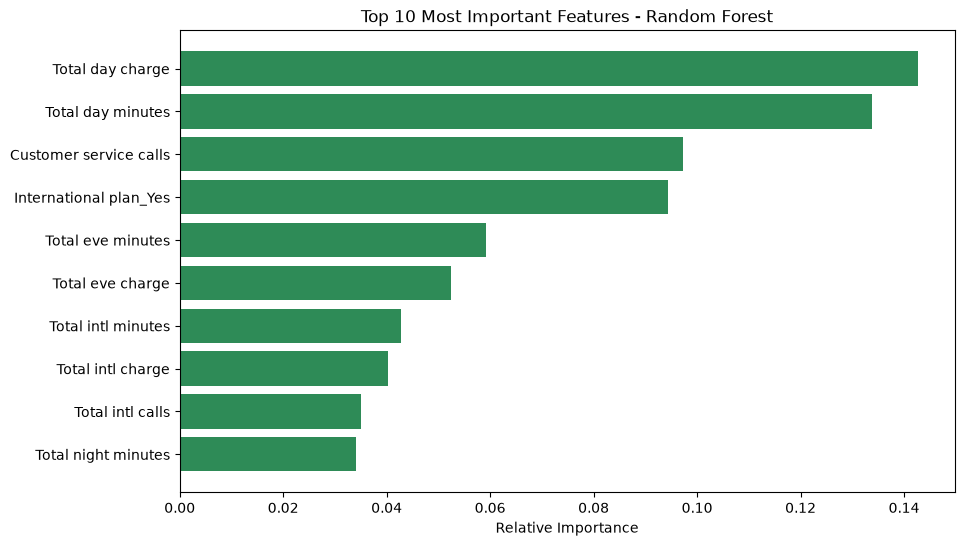

In [3]:
rf_df = pd.read_csv('churn-bigml-80.csv')


le_rf = LabelEncoder()
rf_df['Churn'] = le_rf.fit_transform(rf_df['Churn'])

cat_cols = rf_df.select_dtypes(include=['object', 'bool']).columns.tolist()
if 'Churn' in cat_cols:
    cat_cols.remove('Churn')
rf_df_encoded = pd.get_dummies(rf_df, columns=cat_cols, drop_first=True)


X_rf = rf_df_encoded.drop('Churn', axis=1)
y_rf = rf_df_encoded['Churn']


X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)


rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)


cv_scores = cross_val_score(rf_model, X_train_rf, y_train_rf, cv=5)
print(f"--- Cross-Validation ---")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


y_pred_rf = rf_model.predict(X_test_rf)
print("\n--- Classification Report ---")
print(classification_report(y_test_rf, y_pred_rf))


feature_importances = pd.DataFrame(
    {'Feature': X_rf.columns, 'Importance': rf_model.feature_importances_}
).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'][:10][::-1], feature_importances['Importance'][:10][::-1], color='seagreen')
plt.title('Top 10 Most Important Features - Random Forest')
plt.xlabel('Relative Importance')
plt.show()